In [23]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    average_precision_score, roc_auc_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix,
    precision_recall_curve, roc_curve
)
import lightgbm as lgb
import time
import warnings
warnings.filterwarnings('ignore')
import joblib
from scipy.stats import randint, uniform, loguniform

In [24]:
# 1. Загрузка данных (уже разделённых)
FEATURES_TRAIN_PATH = "../model/features_train.npz"
FEATURES_TEST_PATH = "../model/features_test.npz"
PCA_PATH = "../model/pca.pkl"
SCALER_PATH = "../model/scaler.pkl"

data_train = np.load(FEATURES_TRAIN_PATH)
X_train = data_train["X"]
y_train = data_train["y"]

data_test = np.load(FEATURES_TEST_PATH)
X_test = data_test["X"]
y_test = data_test["y"]

print(f"Размерность X_train: {X_train.shape}")
print(f"Размерность X_test: {X_test.shape}")
print(f"Баланс классов train: {np.bincount(y_train)}")
print(f"Баланс классов test: {np.bincount(y_test)}")

# Загружаем PCA и scaler (для информации, не для трансформации – они уже применены)
with open(PCA_PATH, 'rb') as f:
    pca = pickle.load(f)
with open(SCALER_PATH, 'rb') as f:
    scaler = pickle.load(f)

Размерность X_train: (800, 96)
Размерность X_test: (200, 96)
Баланс классов train: [400 400]
Баланс классов test: [100 100]


In [25]:
# 2. Настройка Hyperparameter Search
# Параметры для поиска
param_dist = {
    'n_estimators': randint(100, 500),
    'learning_rate': loguniform(0.01, 0.3),
    'max_depth': randint(2, 20),
    'num_leaves': randint(10, 100),
    'min_child_samples': randint(5, 20),
    'min_child_weight': loguniform(0.001, 0.6),
    'subsample': uniform(0.7, 0.3),          # 0.7–1.0
    'colsample_bytree': uniform(0.7, 0.3),   # 0.7–1.0
    'reg_lambda': loguniform(0.01, 1.0),
    'reg_alpha': loguniform(0.01, 0.5),       # можно и 0.0 (не использует loguniform, лучше uniform(0,0.5))
    'min_split_gain': loguniform(0.001, 0.5),
    'max_bin': randint(50, 255),
    'bagging_freq': [1],
    'feature_fraction_bynode': uniform(0.7, 0.3),
}

base_model = lgb.LGBMClassifier(
    random_state=42,
    verbose=-1,
    n_jobs=-1,
)

# Стратифицированная 5‑fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# HalvingRandomSearchCV
search = HalvingRandomSearchCV(
    base_model, param_dist,
    resource='n_samples',        # Ресурс — количество строк
    min_resources=25,
    factor=2,
    n_candidates=400,
    cv=cv,
    scoring='average_precision',
    random_state=42,
    n_jobs=1,
    verbose=1
)

print("Начинаем подбор гиперпараметров (только на train)...")
start_time = time.time()
search.fit(X_train, y_train)   # <-- ИСПРАВЛЕНИЕ: используем X_train, y_train
print(f"Подбор завершён за {time.time() - start_time:.2f} сек")

print("\nЛучшие параметры:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Лучший PR-AUC (CV): {search.best_score_:.4f}")

Начинаем подбор гиперпараметров (только на train)...
n_iterations: 6
n_required_iterations: 9
n_possible_iterations: 6
min_resources_: 25
max_resources_: 800
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 400
n_resources: 25
Fitting 5 folds for each of 400 candidates, totalling 2000 fits
----------
iter: 1
n_candidates: 200
n_resources: 50
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
----------
iter: 2
n_candidates: 100
n_resources: 100
Fitting 5 folds for each of 100 candidates, totalling 500 fits
----------
iter: 3
n_candidates: 50
n_resources: 200
Fitting 5 folds for each of 50 candidates, totalling 250 fits
----------
iter: 4
n_candidates: 25
n_resources: 400
Fitting 5 folds for each of 25 candidates, totalling 125 fits
----------
iter: 5
n_candidates: 13
n_resources: 800
Fitting 5 folds for each of 13 candidates, totalling 65 fits
Подбор завершён за 118.17 сек

Лучшие параметры:
  bagging_freq: 1
  colsample_bytree: 0.8300966001869166
 

In [26]:
# 3. Обучение финальной модели
best_params = search.best_params_
final_model = lgb.LGBMClassifier(
    **best_params,
    random_state=42,
    verbose=-1,
    n_jobs=-1,
)

# Обучаем на ВСЁМ train датасете без кросс-валидации
final_model.fit(X_train, y_train)

# 4. Оценка на отложенной выборке

y_pred_proba = final_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

pr_auc = average_precision_score(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===== Метрики на ТЕСТОВОЙ выборке =====")
print(f"PR-AUC (average precision): {pr_auc:.4f}")
print(f"ROC-AUC:                   {roc_auc:.4f}")
print(f"Accuracy:                  {accuracy:.4f}")
print(f"Precision:                 {precision:.4f}")
print(f"Recall:                    {recall:.4f}")
print(f"F1-score:                  {f1:.4f}")

===== Метрики на ТЕСТОВОЙ выборке =====
PR-AUC (average precision): 0.8910
ROC-AUC:                   0.9152
Accuracy:                  0.8550
Precision:                 0.8257
Recall:                    0.9000
F1-score:                  0.8612


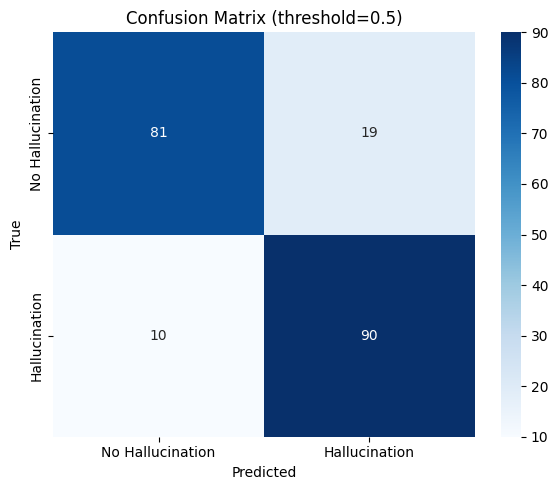

In [27]:
# 5. Визуализация результатов
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Hallucination', 'Hallucination'],
            yticklabels=['No Hallucination', 'Hallucination'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (threshold=0.5)')
plt.tight_layout()
plt.savefig('../model/confusion_matrix.png')
plt.show()

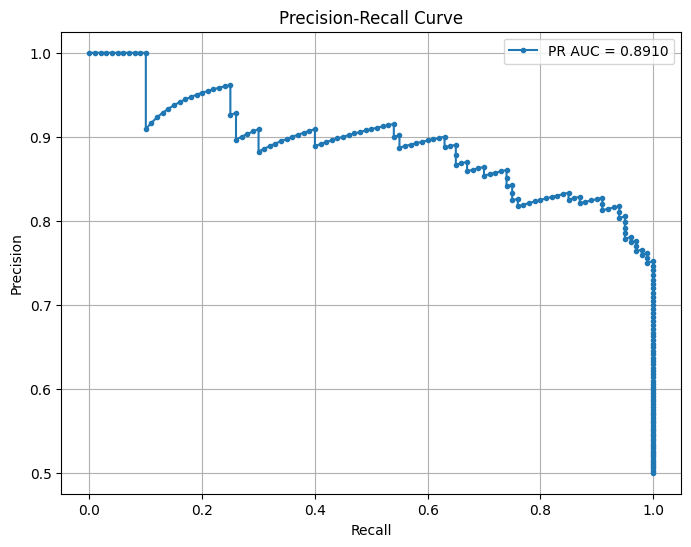

In [28]:
# PR-кривая
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(recall_curve, precision_curve, marker='.', label=f'PR AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.savefig('../model/pr_curve.png')
plt.show()

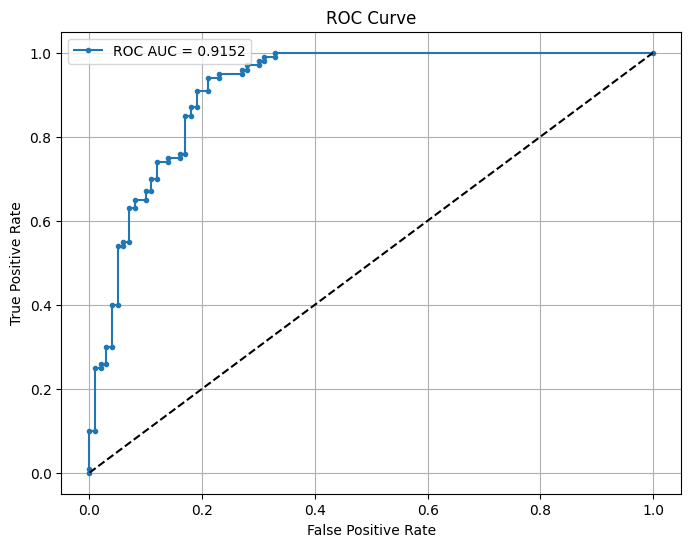

In [29]:
# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, marker='.', label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.savefig('../model/roc_curve.png')
plt.show()

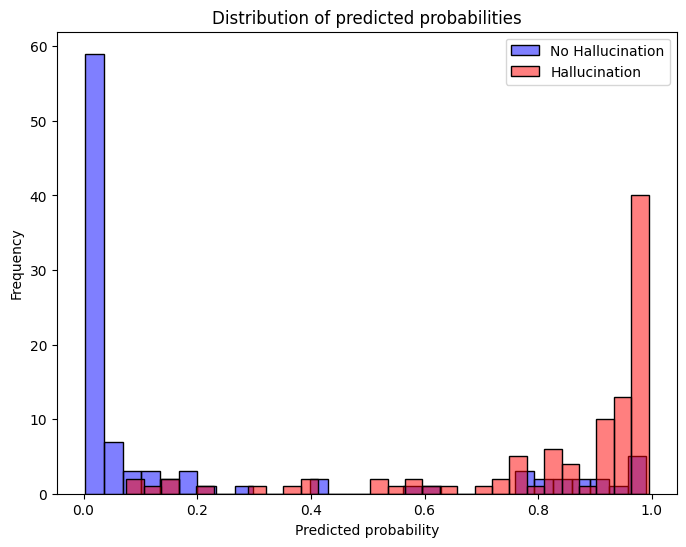

In [30]:
# Распределение вероятностей
plt.figure(figsize=(8,6))
sns.histplot(y_pred_proba[y_test==0], bins=30, color='blue', alpha=0.5, label='No Hallucination')
sns.histplot(y_pred_proba[y_test==1], bins=30, color='red', alpha=0.5, label='Hallucination')
plt.xlabel('Predicted probability')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of predicted probabilities')
plt.savefig('../model/proba_distribution.png')
plt.show()

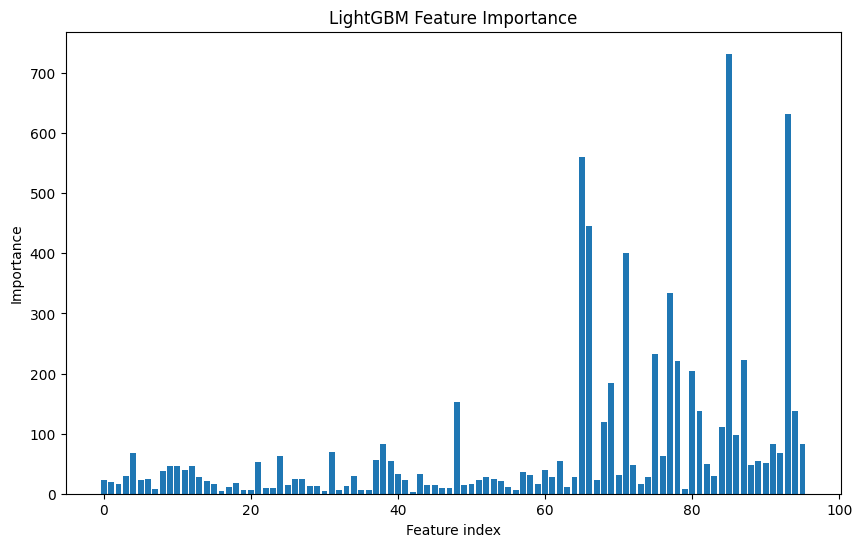

In [31]:
# Важность признаков
feature_importance = final_model.feature_importances_
plt.figure(figsize=(10,6))
plt.bar(range(len(feature_importance)), feature_importance)
plt.xlabel('Feature index')
plt.ylabel('Importance')
plt.title('LightGBM Feature Importance')
plt.savefig('../model/feature_importance.png')
plt.show()

In [32]:
# 6. Сохранение модели
joblib.dump(final_model, "../model/hallucination_detector.pkl")
print("Модель сохранена в model/hallucination_detector.pkl")

Модель сохранена в model/hallucination_detector.pkl
